# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 19. Современные трансформеры`

## `Занятие провел: Мелихов Дмитрий (@dmitrymelikhov)`

## `Материалы составил: Мелихов Дмитрий (@dmitrymelikhov)`


### `Москва, Весенний семестр 2026`

### Источники
- [D2L book](https://d2l.ai) &ndash; учебник по DL, где можно найти базу по Attention и трансформерам и многим другим интересным темам.
- [IBM blog про MHA/MQA/GQA](https://www.ibm.com/think/topics/grouped-query-attention) &ndash; Объяснение реализаций attention.
- [Medium blog про Pre-Norm vs Post-Norm](https://medium.com/@ashutoshs81127/why-pre-norm-became-the-default-in-transformers-4229047e2620) &ndash; пояснение про порядок нормализаций
- [HF blog про MoE](https://huggingface.co/blog/moe) &ndash; блог HuggingFace про Mixture of Experts
---

На прошлых занятиях мы узнали, что такое attention, базовую архитектуру трансформера из статьи "Attention Is All You Need", а также рассмотрели архитектуры и процессы обучения: Bert, T5, GPT2.

Разберём оптимизации механизма внимания: MQA, GQA, а также MLA из DeepSeek.
Поговорим про Mixture of Experts — как модель учится не «думать всеми головами сразу» и почему это позволяет масштабироваться без пропорционального роста вычислений.
Разберём позиционные кодирования: классический sinusoidal PE, ALiBi, относительное кодирование и RoPE — стандарт де-факто в современных LLM.
В конце пройдёмся по нормализациям (LayerNorm, RMSNorm, Pre/Post-Norm) и активациям (GELU, SwiGLU).

---

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Введение

На прошлых парах вам рассказали, как устроены трансформеры. Но если вы попробуете реализовать и обучить как есть, то внезапно заметите, что для обучения адекватной модели необходимо большое количество данных и огромные вычислительные ресурсы.

**BERT** [Devlin J. et al., 2019](https://arxiv.org/abs/1810.04805), примерно 155 тысяч цитирований:
```
Training of BERT BASE was performed on 4 Cloud TPUs in Pod configuration (16 TPU chips total).
13 Training of BERT LARGE was performed on 16 Cloud TPUs (64 TPU chips total).
Each pretraining took 4 days to complete.
```

<font color='Cyan'>**Примечание:**</font> TPU (Tensor Processing Units) - процессоры, которые используют Google. В пересчёте (очень условном) на GPU:

4 Cloud TPU Pod $\approx$ 16 - 32 V100.

По современным меркам BERT - очень маленькие модели (110M, 340M параметров).

Модели побольше GPT-2 XL (1.5B параметров) - около 1 недели.

Очевидно, если мы хотим обучить что-то побольше, нам нужно оптимизировать всё, в том числе и архитектуру. Начнём с центральной идеи трансформера - Attention.


## KV-cache для LLM

Вспомним механизм внимания. Он принимает на вход последовательность токенов и для каждого из них строит три вектора: **запрос** (Query), **ключ** (Key) и **значение** (Value). Формально, имея матрицы $Q$, $K$, $V \in \mathbb{R}^{n \times d}$, выход attention вычисляется как:

$$
SoftMax(\frac{Q K^T \oplus mask}{\sqrt{d}}) V
$$

Здесь $\oplus mask$ — это прибавление маски: для декодера используется верхнетреугольная матрица, которая обнуляет веса будущих токенов, не позволяя позиции $i$ «смотреть» на позиции $j > i$. Деление на $\sqrt{d}$ нормирует скалярные произведения и стабилизирует градиенты.

Теперь рассмотрим инференс. Языковая модель — авторегрессионная: на каждом шаге она принимает уже сгенерированный префикс и предсказывает **один следующий токен**. Если к текущему моменту в контексте $n$ токенов, модель снова прогоняет весь attention: строит $Q$, $K$, $V$ для всех $n$ позиций, перемножает $QK^T$ — это $O(n^2)$ операций — и получает выход.

Затем добавляется новый токен, контекст становится длиной $n+1$, и всё повторяется заново. При длинных последовательностях это катастрофически дорого: большая часть вычислений просто **воспроизводит то, что уже было посчитано на предыдущем шаге**.



Заметим ключевое: при добавлении нового токена $Q$, $K$, $V$ всех **предыдущих** токенов не меняются — ведь их входные эмбеддинги остались прежними. Значит, нам не нужно пересчитывать $K$ и $V$ для всего префикса — достаточно **закэшировать** их после первого прохода и на каждом следующем шаге досчитывать только одну новую строку.

Именно это и делает **KV-cache**: мы храним таблицы ключей и значений для всех уже обработанных позиций и на шаге $n+1$ вычисляем $K_{n+1}$, $V_{n+1}$ только для нового токена, а затем конкатенируем их с кэшем. Запрос $Q$ при этом нужен лишь для последней позиции — единственной, выход которой нас интересует.

[HF blog про KV-cache](https://huggingface.co/blog/not-lain/kv-caching)

## Attention Implementations

Вы уже познакомились с Self-Attention из статьи **Attention Is All You Need** [Vaswani A. et al., 2017](https://arxiv.org/abs/1706.03762), примерно 216 тысяч цитирований. И узнали, что такое Multi-Head self-Attention (MHA). Вспомним что это такое.

### Sliding window attention


<font color='Orange'>**Вопрос:**</font> Почему трансформеры долго учатся?

#### Ответ

Attention - вычислительно сложная операция ($O(L^2)$).

При длинном контексте (>1024 токенов) возникают проблемы со скоростью.

#### Как решить проблему?

Чтобы справиться с данной проблемой, можно просто ограничить контекст до W, и тогда сложность Attention становится $O(L \times W)$

Заметим, что если ширина окна - $W$, то это не значит, что модель видит только последние $W$ токенов. Пусть модель имеет $n\_layers$ слоёв.

На первом слое информация о 1-ом токене известна только $W$-ому токену.

На втором слое информация о 1-ом токене уже известна $2W - 1$-ому токену.

В последнем слое информация (хоть и очень маленькая) о 1-ом токене дойдёт до токена под номером $n\_layers \times W - n\_layers + 1$.

Вы могли вспомнить, что похожая идея возникала в свёртках, когда мы старались увеличить receptive field. Мы можем либо взять 1 свертку с ядром 5, либо 2 последовательные с ядром 3. С трансформерами аналогичная ситуация.

**Sliding Window Attention Training for Efficient Large Language Models** [Fu Z. et al., 2025](https://arxiv.org/abs/2502.18845)

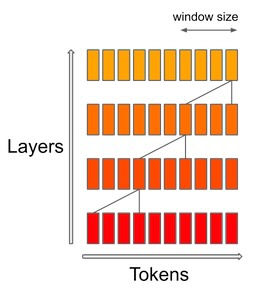

[Источник](https://mistral.ai/news/announcing-mistral-7b/)

Эффективная реализация требует знания CUDA kernels и уже реализована во FlashAttention-2 / xFormers.

### MHA

<font color='Orange'>**Вопрос:**</font> Почему мы перешли к MHA?

#### Ответ

Экономим на вычислениях.

#### Вспомним как работает Multi-Head self-attention

Пусть у нас есть эмбеддинги $X \in \mathbb{R}^{L \times D}$
и маска $mask \in \{0, -\infty\}^{L \times L}$

$mask_{i, j} = -\infty$, если для вычисления attention score для i-го токена нельзя использовать j-й токен.

Мы разбиваем пространство $D$ на $h$ голов: $D = h \times d$

Прогоняем через проекции для каждой головы и получаем:

$$
Q^h = \{q_i = X W_i^Q \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
K^h = \{k_i = X W_i^K \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
V^h = \{v_i = X W_i^V \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$

$W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{d \times d}$ - обучаемые параметры $\forall i = 1,..., h$.

Для каждой головы применяем применяем dot-product attention:

$$
a_i = DotProductAttention(q_i, k_i, v_i, mask) = SoftMax(\frac{q_i k_i^T \oplus mask}{\sqrt{d}}) v_i \in \mathbb{R}^{L \times d}
$$

Полученные скоры конкатенируем и умножаем на обучаемый параметр $W^O$:

$$
A = Concat(\{a_i\}_{i=1}^{h}) W^O \text{ - финальный результат MHA}
$$

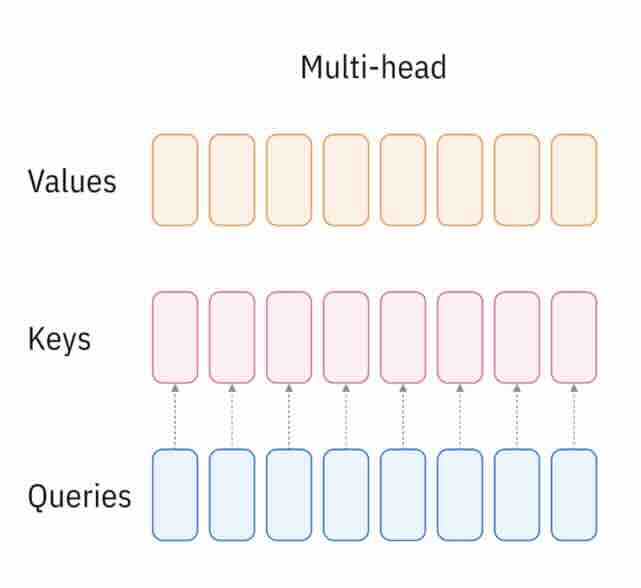

[Источник](https://www.ibm.com/think/topics/grouped-query-attention)

<font color='Orange'>**Вопрос:**</font> Зачем переходим к многоголовости?

#### Ответ:

Мы работаем на маленьких матрицах, это ускоряет работу и на практике приводит к более стабильным вычилениям

#### Реализация MHA

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        Multi-Head Attention механизм

        Args:
            d_model: размерность модели (в наших вычислениях это D)
            num_heads: количество голов внимания (в наших вычислениях это h)
        """
        super(MultiHeadAttention, self).__init__()

        assert d_model % num_heads == 0, "d_model должен делиться на num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # размерность каждой головы

        # Линейные слои для Q, K, V
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)

        # Выходной линейный слой
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(self, query, key, value, mask=None):
        """
        Forward pass для Multi-Head Attention

        Args:
            query: тензор [batch_size, seq_len_q, d_model]
            key: тензор [batch_size, seq_len_k, d_model]
            value: тензор [batch_size, seq_len_v, d_model]
            mask: опциональная маска [batch_size, 1, seq_len_q, seq_len_k]

        Returns:
            output: тензор [batch_size, seq_len_q, d_model]
            attention_weights: тензор [batch_size, num_heads, seq_len_q, seq_len_k]
        """
        batch_size = query.size(0)
        seq_len_q = query.size(1)
        seq_len_k = key.size(1)

        # Применяем линейные преобразования: [batch_size, seq_len, d_model]
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)

        # Разбиваем на головы: [batch_size, seq_len, num_heads, d_k]
        Q = Q.view(batch_size, seq_len_q, self.num_heads, self.d_k)
        K = K.view(batch_size, seq_len_k, self.num_heads, self.d_k)
        V = V.view(batch_size, seq_len_k, self.num_heads, self.d_k)

        # Transpose для удобства: [batch_size, num_heads, seq_len, d_k]
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Вычисляем scaled dot-product attention
        # scores: [batch_size, num_heads, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Применяем маску (если есть)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Применяем softmax
        attention_weights = torch.softmax(scores, dim=-1)

        # Умножаем на V: [batch_size, num_heads, seq_len_q, d_k]
        attn_output = torch.matmul(attention_weights, V)

        # Объединяем головы: [batch_size, seq_len_q, num_heads, d_k]
        attn_output = attn_output.transpose(1, 2).contiguous()

        # Reshape: [batch_size, seq_len_q, d_model]
        attn_output = attn_output.view(batch_size, seq_len_q, self.d_model)

        # Применяем финальную линейную трансформацию
        output = self.W_o(attn_output)

        return output, attention_weights

### MQA

Теперь давайте подумаем, как можно ускорить вычисления. Посмотрим ещё раз на MHA:

$$
Q^h = \{q_i = X W_i^Q \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
K^h = \{k_i = X W_i^K \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
V^h = \{v_i = X W_i^V \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$

Всего обучаемых параметров: $d \times d \times (3h)$. Давайте немного сэкономим и для каждой головы будем использовать один и тот же вес для K и V:

$$
W_i^K = W^K, \forall i = 1,..., h
$$
$$
W_i^V = W^V, \forall i = 1,..., h
$$

Теперь обучаемых параметров: $d \times d \times (h + 2)$.

Данный подход называется Multi-Query Attention (MQA).

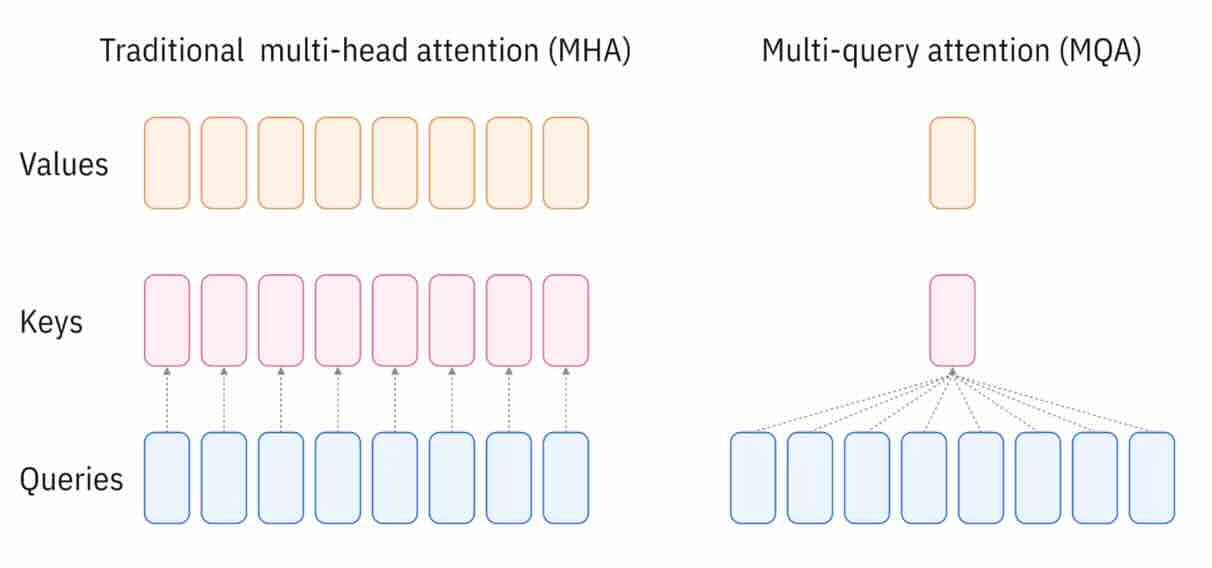

[Источник](https://www.ibm.com/think/topics/grouped-query-attention)

<font color='Orange'>**Вопрос:**</font> Почему не делаем для Q один и тот же вес?

#### Ответ:

Если сделать для Q один и тот же вес для всех голов, то мы лишимся многоголовости



#### Реализация MQA

In [ ]:
class MultiQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        """
        Multi-Query Attention механизм
        В MQA: Q имеет несколько голов, но K и V имеют только одну голову

        Args:
            d_model: размерность модели (embedding dimension)
            num_heads: количество голов для Query
        """
        super(MultiQueryAttention, self).__init__()

        assert d_model % num_heads == 0, "d_model должен делиться на num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # размерность каждой головы Query

        # Линейные слои
        self.W_q = nn.Linear(d_model, d_model)  # Query: num_heads голов
        self.W_k = nn.Linear(d_model, self.d_k)  # Key: только одна голова
        self.W_v = nn.Linear(d_model, self.d_k)  # Value: только одна голова

        # Выходной линейный слой
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        """
        Forward pass для Multi-Query Attention

        Args:
            query: тензор [batch_size, seq_len_q, d_model]
            key: тензор [batch_size, seq_len_k, d_model]
            value: тензор [batch_size, seq_len_v, d_model]
            mask: опциональная маска [batch_size, 1, seq_len_q, seq_len_k]

        Returns:
            output: тензор [batch_size, seq_len_q, d_model]
            attention_weights: тензор [batch_size, num_heads, seq_len_q, seq_len_k]
        """
        batch_size = query.size(0)
        seq_len_q = query.size(1)
        seq_len_k = key.size(1)

        # Query: применяем линейное преобразование и разбиваем на головы
        # [batch_size, seq_len_q, d_model] -> [batch_size, seq_len_q, num_heads, d_k]
        Q = self.W_q(query)
        Q = Q.view(batch_size, seq_len_q, self.num_heads, self.d_k)
        Q = Q.transpose(1, 2)  # [batch_size, num_heads, seq_len_q, d_k]

        # Key и Value: одна голова для всех
        # [batch_size, seq_len_k, d_model] -> [batch_size, seq_len_k, d_k]
        K = self.W_k(key)
        V = self.W_v(value)

        # Расширяем K и V для всех голов Query
        # [batch_size, seq_len_k, d_k] -> [batch_size, 1, seq_len_k, d_k] -> [batch_size, num_heads, seq_len_k, d_k]
        K = K.unsqueeze(1).expand(batch_size, self.num_heads, seq_len_k, self.d_k)
        V = V.unsqueeze(1).expand(batch_size, self.num_heads, seq_len_k, self.d_k)

        # Вычисляем scaled dot-product attention
        # scores: [batch_size, num_heads, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Применяем маску (если есть)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Применяем softmax
        attention_weights = torch.softmax(scores, dim=-1)

        # Умножаем на V: [batch_size, num_heads, seq_len_q, d_k]
        attn_output = torch.matmul(attention_weights, V)

        # Объединяем головы: [batch_size, seq_len_q, num_heads, d_k]
        attn_output = attn_output.transpose(1, 2).contiguous()

        # Reshape: [batch_size, seq_len_q, d_model]
        attn_output = attn_output.view(batch_size, seq_len_q, self.d_model)

        # Применяем финальную линейную трансформацию
        output = self.W_o(attn_output)

        return output, attention_weights


### GQA

MQA - позволяет снизить число параметров, но это слишком радикальное решение. Из-за этого сильно падает качество модели. Есть ли какое-то решение посередине?

$$
Q^h = \{q_i = X W_i^Q \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
K^h = \{k_i = X W_i^K \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$
$$
V^h = \{v_i = X W_i^V \in \mathbb{R}^{L \times d}\}_{i=1}^{h}
$$

Что если мы будем использовать не одни и те же веса для всех K, V, а разделим головы на группы и внутри одной группы будут одни и те же веса?

$G \in \{1, ..., h\}$ - размер группы.

$g(i)$ - функция, которая ставит в соответствие номер головы - номеру группы.

Например: $g(i) = \bigl \lfloor \frac{i}{G} \bigr\rfloor$

Тогда разделим параметры между головами следующим образом:

$$
W_i^K := \bar{W}_{g(i)}^K, \forall i = 1,..., h
$$
$$
W_i^V := \bar{W}_{g(i)}^V, \forall i = 1,..., h
$$

Теперь обучаемых параметров: $d \times d \times (h + 2G)$. Вводится новый гиперпараметр $G$.

Такой подход называется Grouped Query Attention (GQA).

Рассмотрим краевые случаи:

1. $\mathbf{G = 1}$: 1 группа - 1 голова. По сути, это тот же MHA.

$$
g(i) = i
$$

$$
W_i^K = \bar{W}_{g(i)}^K = \bar{W}_{i}^K
$$


2. $G = h$: 1 группа - h голов. В одной группе - все головы, это MQA.

$$
g(i) = 0
$$

$$
W_i^K = \bar{W}_{g(i)}^K = \bar{W}_{0}^K
$$

Таким образом GQA - обобщение над MHA и MQA. Это более гибкая реализация, которая позволит разменивать скорость на качество через гиперпараметр.

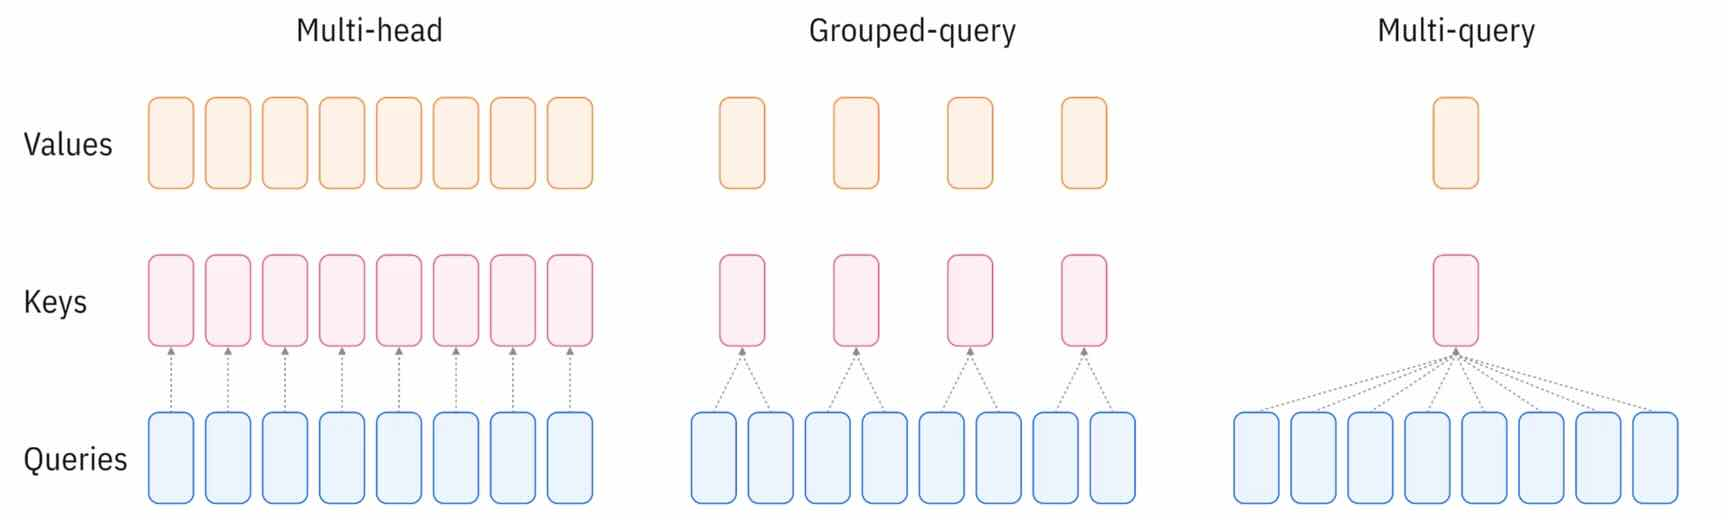

[Источник](https://www.ibm.com/think/topics/grouped-query-attention)

#### Реализация GQA

In [ ]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, d_model, num_heads, num_kv_heads=None):
        """
        Grouped Query Attention механизм
        В GQA: Q имеет num_heads голов, K и V имеют num_kv_heads голов (num_kv_heads < num_heads)
        Каждая KV голова используется группой Query голов

        Args:
            d_model: размерность модели (embedding dimension)
            num_heads: количество голов для Query
            num_kv_heads: количество голов для Key и Value (по умолчанию num_heads // 2)
        """
        super(GroupedQueryAttention, self).__init__()

        assert d_model % num_heads == 0, "d_model должен делиться на num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.num_kv_heads = num_kv_heads if num_kv_heads is not None else num_heads // 2

        assert num_heads % self.num_kv_heads == 0, "num_heads должен делиться на num_kv_heads"
        assert self.num_kv_heads > 0, "num_kv_heads должен быть > 0"

        self.d_k = d_model // num_heads  # размерность каждой головы
        self.num_groups = num_heads // self.num_kv_heads  # количество Query голов на одну KV голову

        # Линейные слои
        self.W_q = nn.Linear(d_model, d_model)  # Query: num_heads голов
        self.W_k = nn.Linear(d_model, self.num_kv_heads * self.d_k)  # Key: num_kv_heads голов
        self.W_v = nn.Linear(d_model, self.num_kv_heads * self.d_k)  # Value: num_kv_heads голов

        # Выходной линейный слой
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, query, key, value, mask=None):
        """
        Forward pass для Grouped Query Attention

        Args:
            query: тензор [batch_size, seq_len_q, d_model]
            key: тензор [batch_size, seq_len_k, d_model]
            value: тензор [batch_size, seq_len_v, d_model]
            mask: опциональная маска [batch_size, 1, seq_len_q, seq_len_k]

        Returns:
            output: тензор [batch_size, seq_len_q, d_model]
            attention_weights: тензор [batch_size, num_heads, seq_len_q, seq_len_k]
        """
        batch_size = query.size(0)
        seq_len_q = query.size(1)
        seq_len_k = key.size(1)

        # Query: применяем линейное преобразование и разбиваем на num_heads голов
        # [batch_size, seq_len_q, d_model] -> [batch_size, num_heads, seq_len_q, d_k]
        Q = self.W_q(query)
        Q = Q.view(batch_size, seq_len_q, self.num_heads, self.d_k)
        Q = Q.transpose(1, 2)  # [batch_size, num_heads, seq_len_q, d_k]

        # Key и Value: применяем линейное преобразование и разбиваем на num_kv_heads голов
        # [batch_size, seq_len_k, d_model] -> [batch_size, num_kv_heads, seq_len_k, d_k]
        K = self.W_k(key)
        V = self.W_v(value)

        K = K.view(batch_size, seq_len_k, self.num_kv_heads, self.d_k)
        V = V.view(batch_size, seq_len_k, self.num_kv_heads, self.d_k)

        K = K.transpose(1, 2)  # [batch_size, num_kv_heads, seq_len_k, d_k]
        V = V.transpose(1, 2)  # [batch_size, num_kv_heads, seq_len_k, d_k]

        # Повторяем каждую KV голову num_groups раз для соответствующих Query голов
        # [batch_size, num_kv_heads, seq_len_k, d_k] -> [batch_size, num_heads, seq_len_k, d_k]
        K = K.repeat_interleave(self.num_groups, dim=1)
        V = V.repeat_interleave(self.num_groups, dim=1)

        # Вычисляем scaled dot-product attention
        # scores: [batch_size, num_heads, seq_len_q, seq_len_k]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Применяем маску (если есть)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Применяем softmax
        attention_weights = torch.softmax(scores, dim=-1)

        # Умножаем на V: [batch_size, num_heads, seq_len_q, d_k]
        attn_output = torch.matmul(attention_weights, V)

        # Объединяем головы: [batch_size, seq_len_q, num_heads, d_k]
        attn_output = attn_output.transpose(1, 2).contiguous()

        # Reshape: [batch_size, seq_len_q, d_model]
        attn_output = attn_output.view(batch_size, seq_len_q, self.d_model)

        # Применяем финальную линейную трансформацию
        output = self.W_o(attn_output)

        return output, attention_weights

NameError: name 'nn' is not defined

### MLA

Вспомним про KV-cache. Он оптимизирует инференс, но при этом потребялет много памяти.

MLA, предложенный в модели [DeepSeek-V2](arxiv.org/abs/2405.04434?), решает эту проблему через низкоранговое сжатие. Вместо того чтобы хранить полные $K$ и $V$ для каждого токена, модель обучается проецировать их в компактный **латентный вектор** $c \in \mathbb{R}^{d_c}$, где $d_c \ll n_{heads} \cdot d_{head}$:

$$
c_t = W_{down} \, h_t
$$

где $h_t$ — скрытое состояние токена $t$, а $W_{down}$ — обучаемая матрица «сжатия». В кэше хранится именно $c_t$, а не полные $K$ и $V$. На этапе вычисления attention ключи и значения **восстанавливаются** из латентного вектора:

$$
K_t = W_{up}^K \, c_t, \qquad V_t = W_{up}^V \, c_t
$$

Таким образом, вместо хранения $2 \times n_{heads} \times d_{head}$ чисел на токен достаточно хранить $d_c$ чисел — сжатие может быть в **5–10 раз** по объёму кэша.

Аналогичное сжатие применяется и к запросам, только его не нужно кэшировать — $Q$ вычисляется заново на каждом шаге:

$$
q_t = W_{up}^Q \, (W_{down}^Q \, h_t)
$$

Это bottleneck-структура: сначала проекция вниз, потом вверх. По сути, обычный low-rank adapter прямо внутри механизма внимания.

MLA — это компромисс между памятью и вычислениями: мы тратим чуть больше FLOPs на восстановление $K$ и $V$ из латентного вектора, зато радикально сокращаем объём кэша. При длинных контекстах и большом батче именно память становится главным ограничением инференса — и MLA решает ровно эту проблему, не жертвуя качеством модели.

## MoE

Посмотрим, что ещё можно соптимизировать в трансформере.

<font color='Orange'>**Вопрос:**</font> Какая часть трансформера самая тяжёлая по параметрам?

#### Ответ:

Cамая тяжёлая по весам части трансформера - FFN. Она представляет из себя 2-слойную MLP: $2 \times D \times D_{FFN}$ параметров, где $D_{FFN}$ - ширина внутреннего слоя (обычно $D_{FFN} = 8D$).

#### Как оптимизируем?

Как можно уменьшить число параметров?

Напрямую без потери качества - почти никак.

Подумаем немного в обратную сторону - допустим, мы можем себе позволить много памяти. Можем ли мы использовать больше памяти, но при этом быстро инферить модели? В теории хотим так, чтобы модель была быстрой, но при этом умной, а цена, которую мы за это заплатим - память (RAM).

Есть подход, который подходит к данной проблеме - Mixture of Experts (MoE)

Предлагается обучать несколько голов FFN, но использовать не все, а только необходимые. Так мы будем хранить много весов, но использовать их эффективно (в теории). Здесь MoE реализован очень наивно, чтобы была понятна суть метода.

#### Expert

Давайте попробуем применить такой же трюк, как в Attention - сделаем несколько голов (назовём их **экспертами**).

**Эксперт** - обычная FFN.

In [ ]:
class Expert(nn.Module):
    """Один эксперт - стандартная feed-forward сеть"""
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # FFN: W2(dropout(gelu(W1(x))))
        return self.w2(self.dropout(F.gelu(self.w1(x))))

NameError: name 'nn' is not defined

#### Router

Для ускорения инференса, мы не будем использовать все головы, а только часть. Чтобы понять, каких экспертов используем, будем обучать отдельную модель, которую мы назовём **router**. Этот модуль будет предсказывать, каких экспертов для выбранного токена нужно использовать.

В целях экономии памяти, в качестве router мы возьмём обычную линейную модель. Выбор экспертов проведём через top-k семплирование.

In [ ]:
class TopKRouter(nn.Module):
    """Роутер для выбора top-K экспертов"""
    def __init__(self, d_model, num_experts, top_k, capacity_factor=1.0):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.capacity_factor = capacity_factor

        # Gating network - простой линейный слой
        self.gate = nn.Linear(d_model, num_experts)

    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len, d_model]
        Returns:
            router_weights: [batch_size, seq_len, top_k]
            selected_experts: [batch_size, seq_len, top_k]
        """
        batch_size, seq_len, d_model = x.shape

        # Вычисляем веса для всех экспертов
        logits = self.gate(x)  # [batch, seq_len, num_experts]

        # Применяем softmax для получения вероятностей
        router_probs = F.softmax(logits, dim=-1)

        # Выбираем top-k экспертов
        router_weights, selected_experts = torch.topk(
            router_probs, self.top_k, dim=-1
        )

        # Нормализуем веса выбранных экспертов
        router_weights = router_weights / router_weights.sum(dim=-1, keepdim=True)

        return router_weights, selected_experts

#### MoE

Теперь соберём всё вместе. Для каждого токена прогоняем через роутер, чтобы решить через каких экспертов он должен пройти, и используем только выбранных экспертов.

Данная реализация недостаточно эффективная, в идеале нужно итерироваться по экспертам, но в качестве демонстрации рассмотрим такую версию:


In [ ]:
class MoELayer(nn.Module):
    """Mixture of Experts layer"""
    def __init__(self, d_model, d_ff, num_experts=8, top_k=2, dropout=0.1):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k

        # Создаем экспертов
        self.experts = nn.ModuleList([
            Expert(d_model, d_ff, dropout) for _ in range(num_experts)
        ])

        # Роутер
        self.router = TopKRouter(d_model, num_experts, top_k)

    def forward(self, x):
        """
        Args:
            x: [batch_size, seq_len, d_model]
        Returns:
            output: [batch_size, seq_len, d_model]
        """
        batch_size, seq_len, d_model = x.shape

        # Получаем веса и индексы выбранных экспертов
        router_weights, selected_experts = self.router(x)
        # router_weights: [batch, seq_len, top_k]
        # selected_experts: [batch, seq_len, top_k]

        # Инициализируем выходной тензор
        output = torch.zeros_like(x)

        # Простая реализация: обрабатываем каждый токен отдельно
        # (в production используются более эффективные методы)
        for batch_idx in range(batch_size):
            for seq_idx in range(seq_len):
                token = x[batch_idx, seq_idx:seq_idx+1]  # [1, d_model]

                # Обрабатываем выбранными экспертами
                for k in range(self.top_k):
                    expert_idx = selected_experts[batch_idx, seq_idx, k].item()
                    weight = router_weights[batch_idx, seq_idx, k]

                    expert_output = self.experts[expert_idx](token)
                    output[batch_idx, seq_idx] += weight * expert_output.squeeze(0)

        return output

#### Как всё работает вместе

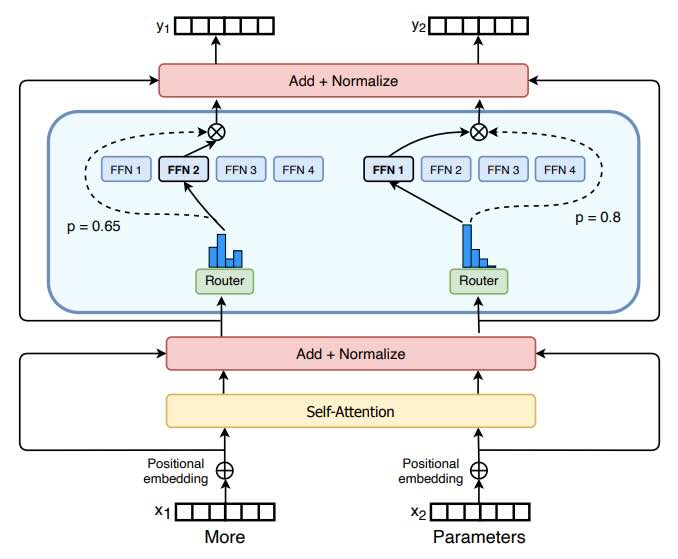

[Источник](https://huggingface.co/blog/moe)

### Выводы по методу

Основные сложности метода:
1. Неравномерна нагрузка на экспертов: через некоторых экспертов может проходить больше токенов, из-за этого некоторые эксперты могут недообучиться
2. MoE очень тяжело обучать из-за дискретизации на этапе top-k семплирования.
3. В теории эксперты могут специализироваться на разных доменах, но на практике специализация не очевидна

MoE - отдельный мир, такие модели требуют тонкого подхода балансировки голов, подбора данных и гиперпараметров.

## Positional Encoding

Следующий важный элемент трансформера, в который мы углубимся - Positional Encoding (**PE**).

<font color='Orange'>**Вопрос:**</font> Зачем нужен Positional Encoding?

#### Ответ:

 В attention никак не учитывается информация о позиции токенов, мы просто считаем веса для токенов в контексте. Поэтому мы добавляем к эмбеддингам информацию по позиции токена. PE необходим в подсчёте весов attention.

### Классический PE

Вспомним как работает классический PE из Attention is All You Need.

Для позиции $\text{pos}$ и измерения $i$ формулы выглядят так:

$$
PE_{(\text{pos}, 2i)} = \sin\left(\frac{\text{pos}}{10000^{2i/D}}\right)
$$

$$PE_{(\text{pos}, 2i+1)} = \cos\left(\frac{\text{pos}}{10000^{2i/D}}\right)$$

где:
- $\text{pos}$ — позиция токена в последовательности
- $i$ — индекс измерения в векторе эмбеддинга (0, 1, 2, ..., $D/2 - 1$)
- $D$ — размерность модели

Четные измерения используют синус, нечетные — косинус. Для каждой пары измерений $(2i, 2i+1)$ используется своя частота, определяемая знаменателем $10000^{2i/D}$.

In [ ]:
# Источник: https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html

class PositionalEncoding(nn.Module):
    """
    Positional encoding.
    """
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        # Create a long enough P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

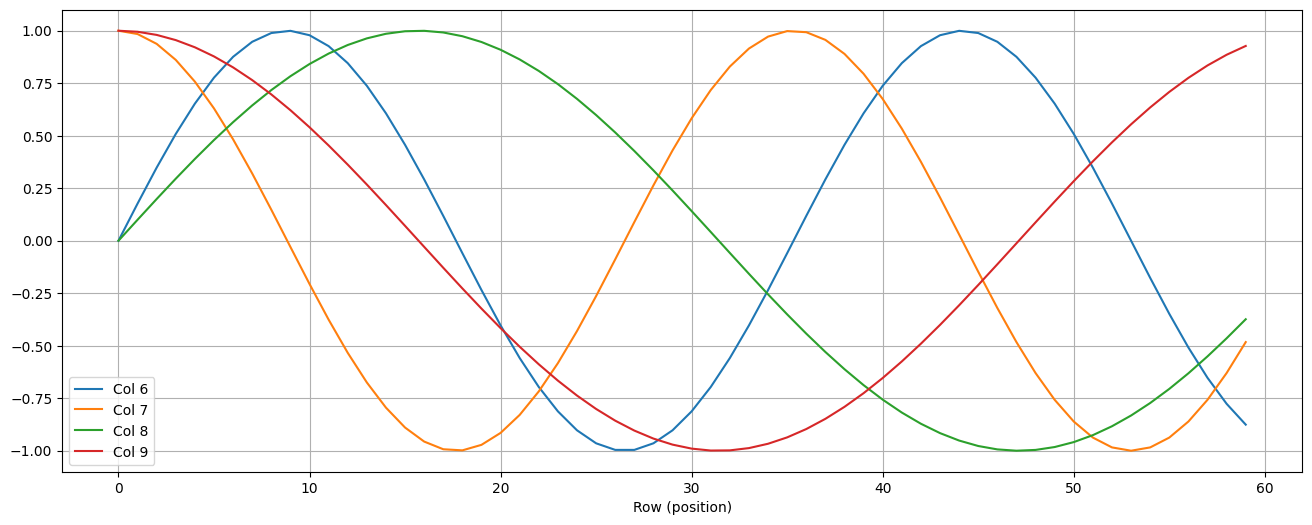

In [ ]:
# Источник: https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html
plt.figure(figsize=(16, 6), dpi=100)

encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]

for i in range(6, 10):
    plt.plot(torch.arange(num_steps), P[0, :, i], label=f"Col {i}")
plt.xlabel('Row (position)')
plt.legend()
plt.grid()
plt.show()

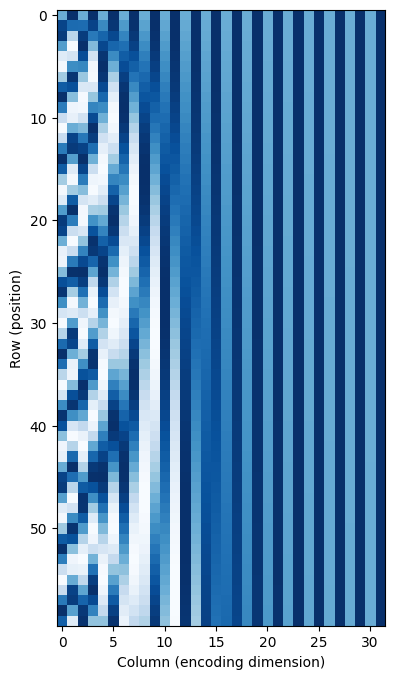

In [ ]:
# Источник: https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html
plt.figure(figsize=(8, 8), dpi=100)

plt.imshow(P[0, :, :], cmap='Blues')
plt.xlabel('Column (encoding dimension)')
plt.ylabel('Row (position)')

plt.show()

Чтобы понять логику, давайте посмотрим на то как кодируются числа в бинарной системе

In [ ]:
for i in range(8):
    print(f'{i} -> {i:>03b}')

0 -> 000
1 -> 001
2 -> 010
3 -> 011
4 -> 100
5 -> 101
6 -> 110
7 -> 111


Здесь мы видим периодичность: меньше бит - выше частота. Классический PE работает так же, только использует тригонометрию.

Классический PE учитывает относительную информацию следующим образом.

Для любого фиксированного смещения $\delta$ позиционное кодирование в позиции $i + \delta$ может быть представлено через линейное преобразование кодирования в позиции $i$.

Обозначим $\omega_j = \frac{1}{10000^{2j/D}}$.

Тогда любая пара $(p_{i, 2j}, p_{i, 2j+1})$ может быть линейно спроецирована на $(p_{i+\delta, 2j}, p_{i+\delta, 2j+1})$ через матрицу поворота:

$$
\begin{aligned}
\begin{bmatrix} \cos(\delta \omega_j) & \sin(\delta \omega_j) \\ -\sin(\delta \omega_j) & \cos(\delta \omega_j) \end{bmatrix}
\begin{bmatrix} p_{i, 2j} \\ p_{i, 2j+1} \end{bmatrix}
&= \begin{bmatrix} \cos(\delta \omega_j) \sin(i \omega_j) + \sin(\delta \omega_j) \cos(i \omega_j) \\ -\sin(\delta \omega_j) \sin(i \omega_j) + \cos(\delta \omega_j) \cos(i \omega_j) \end{bmatrix}\\[10pt]
&= \begin{bmatrix} \sin\left((i+\delta) \omega_j\right) \\ \cos\left((i+\delta) \omega_j\right) \end{bmatrix}\\[10pt]
&= \begin{bmatrix} p_{i+\delta, 2j} \\ p_{i+\delta, 2j+1} \end{bmatrix}
\end{aligned}
$$

**Ключевой момент:** Матрица поворота не зависит от индекса позиции токена.

Красиво, жаль бесполезно. Классический PE не используют в современных LLM. Если задуматься, в понимании текста важнее знать не абсолютное положение токена в контексте, а относительное: чем ближе слова, тем больше вероятность что они связаны $\Rightarrow$ больше вес в attention. Относительная информация учитывается в PE, но она слишком неявная и из-за этого возникают проблемы в обучении.

[D2L про Attention и PE](https://d2l.ai/chapter_attention-mechanisms-and-transformers/self-attention-and-positional-encoding.html)

### Позиция PE

Первое на что мы обратим внимание - на позицию. В классическом трансформере PE стоит вначале, сразу после эмбеддингов.

<font color='Orange'>**Вопрос:**</font> какие проблемы возникают при таком подходе?

#### Ответ

Проблема PE в начале трансформера - потеря информации. С каждым слоем позиционная информация теряется, и обучение замедляется.

#### Где его место?

Позиционная информация необходима только в Attention. В FFN она не нужно, MLP применяется по каждому токену отдельно.

Тогда просто перенесём PE из начала трансформера в Attention. И если подумать, позиционная информация необходима только при подсчёте весов attention (внутри softmax), поэтому добавим PE именно туда.

Вот так выглядит DotProductAttention в классическом трансформере:

$$
DotProductAttention(Q, K, V, mask) = SoftMax(\frac{Q K^T \oplus mask}{\sqrt{d}}) V
$$

После переноса PE в Attention будет выглядеть примерно так:

$$
DotProductAttention(Q, K, V, mask) = SoftMax(\frac{f(Q, K) \oplus mask}{\sqrt{d}}) V
$$

Где f - функция на основе скалярного произведения, которая учитывает позиции токенов.

Этим мы решаем 2 проблемы:
1. Учитываем позицию только там где нужно (в Attention).
2. Мы можем быть уверены, что позиционная информация используется в каждом слое Attention.

Когда мы определились с позицией PE в архитектуре, рассмотрим сам механизм PE

### ALiBi

Нам важно учитывать относительную позицию токенов более явно. В классическом PE относительная позиция слишком сильно зашифрована и могут возникнуть проблемы с масштабированием.

Попробуем учитывать относительную позицию напрямую через штрафы - чем дальше токены, тем выше штраф. Так мы приходим к методу ALiBi (Attention with Linear Biases), предложенный в статье **Train Short, Test Long** [Press et al., 2022](https://arxiv.org/abs/2108.12409) примерно 1200 цитирований.

Вместо модификации Q и K мы добавляем штраф к готовым скорам (пример для декодеров):
$$
SoftMax(Q_i K^T + m \cdot [-(i-1), -(i-2), \ldots, -1, 0])
$$

где:
- $m$ — scalar head-specific slope (у каждой attention head своё значение)
- $[-(i-1), -(i-2), \ldots, -1, 0]$ — расстояния между query на позиции $i$ и всеми keys

Геометрически: ALiBi штрафует внимание к далёким токенам пропорционально расстоянию. Чем дальше key от query, тем сильнее негативный bias.

Плюсы ALiBi по сравнению с классическим PE:
- Классический PE плохо работает на последовательностях длиннее тех, на которых модель обучалась. ALiBi позволяет модели обобщаться на более длинные контексты без дополнительного обучения. Например, модель, обученная на 512 токенах с ALiBi, может работать на 2048+ токенах с минимальной деградацией качества.
- AliBi **не требует дополнительных параметров** (PE добавляет $n \times d$ параметров), **не нужно суммировать эмбеддинги с позициями** => меньше вычислений.
- ALiBi явно кодирует предпочтение к близким токенам через линейное затухание. Это естественное предположение для многих задач (локальность в языке).
- Классический PE может создавать артефакты при больших длинах, так как синусоиды начинают повторяться. ALiBi линеен и предсказуем.

Какие проблемы приходят с ALiBi:
- Линейное затухание может быть слишком жёстким для некоторых паттернов внимания
- Не подходит для задач, где важны абсолютные позиции (например, некоторые structured prediction задачи)

#### Код ALiBi + MHA

In [ ]:
class ALiBiAttention(nn.Module):
    """
    Multi-head attention с ALiBi (Attention with Linear Biases)
    """
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Проекции для Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

        # Slopes для каждой головы (не обучаемые параметры)
        self.register_buffer('slopes', self._get_slopes(num_heads))

    def _get_slopes(self, num_heads):
        """
        Генерирует slopes для каждой attention head
        Формула из статьи: m = 2^(-8/n * i) для i = 1, ..., n
        где n - количество голов
        """
        # Для степеней двойки
        def get_slopes_power_of_2(n):
            start = 2 ** (-8 / n)
            ratio = start
            return [start * (ratio ** i) for i in range(n)]

        # Если num_heads не степень двойки
        if math.log2(num_heads).is_integer():
            slopes = get_slopes_power_of_2(num_heads)
        else:
            # Берём ближайшую степень двойки
            closest_power_of_2 = 2 ** math.floor(math.log2(num_heads))
            slopes = get_slopes_power_of_2(closest_power_of_2)
            # Добавляем дополнительные slopes
            extra = num_heads - closest_power_of_2
            slopes += get_slopes_power_of_2(2 * closest_power_of_2)[:extra]

        return torch.tensor(slopes)

    def _get_alibi_bias(self, seq_len, device):
        """
        Создаёт ALiBi bias матрицу размера (num_heads, seq_len, seq_len)

        Для каждой позиции i bias = -m * расстояние
        где расстояние = |i - j| для query i и key j
        """
        # Создаём матрицу расстояний
        # context_position: [0, 1, 2, ..., seq_len-1]
        context_position = torch.arange(seq_len, device=device).unsqueeze(0)  # (1, seq_len)
        # memory_position: [[0], [1], [2], ..., [seq_len-1]]
        memory_position = torch.arange(seq_len, device=device).unsqueeze(1)   # (seq_len, 1)

        # Матрица относительных расстояний (i - j)
        # Для каждой query позиции i: [-(i-0), -(i-1), ..., -1, 0]
        relative_position = memory_position - context_position  # (seq_len, seq_len)

        # Применяем slopes: (num_heads, 1, 1) * (1, seq_len, seq_len)
        alibi_bias = self.slopes.view(-1, 1, 1) * relative_position.unsqueeze(0)

        return alibi_bias  # (num_heads, seq_len, seq_len)

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: (batch_size, seq_len, d_model)
            key: (batch_size, seq_len, d_model)
            value: (batch_size, seq_len, d_model)
            mask: optional (batch_size, seq_len, seq_len)

        Returns:
            output: (batch_size, seq_len, d_model)
            attention_weights: (batch_size, num_heads, seq_len, seq_len)
        """
        batch_size, seq_len, _ = query.shape

        # Линейные проекции и разделение на головы
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, num_heads, d_k)
        Q = self.W_q(query).view(batch_size, seq_len, self.num_heads, self.d_k)
        K = self.W_k(key).view(batch_size, seq_len, self.num_heads, self.d_k)
        V = self.W_v(value).view(batch_size, seq_len, self.num_heads, self.d_k)

        # Transpose для attention: (batch_size, num_heads, seq_len, d_k)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Scaled dot-product attention scores
        # (batch_size, num_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Добавляем ALiBi bias
        # (num_heads, seq_len, seq_len) -> (1, num_heads, seq_len, seq_len)
        alibi_bias = self._get_alibi_bias(seq_len, query.device).unsqueeze(0)
        scores = scores + alibi_bias

        # Применяем mask (если есть)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        # Softmax
        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        # Применяем attention к values
        # (batch_size, num_heads, seq_len, d_k)
        output = torch.matmul(attention_weights, V)

        # Concatenate heads
        # (batch_size, seq_len, num_heads, d_k) -> (batch_size, seq_len, d_model)
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # Финальная проекция
        output = self.W_o(output)

        return output, attention_weights

### Relative positional encoding

ALiBi слишком просто штрафует за расстояние, хотелось бы видеть полноценные эмбеддинги, но при этом учитывалась относительная информация. Рассмотрим "обычный" механизм внимания с позиционными эмбеддингами и попробуем его модифицировать.

Допустим, $E_{x_{i}}$ — эмбеддинг токена в позиции $i$, $U_{i}$ — позиционный эмбеддинг для позиции $i$, а матрицы $W_{q}, W_{k}, W_{v}$ — проекторы эмбеддингов в запросы, ключи и значения (смещения при вычислении запросов, ключей и значений опущены для краткости).

Тогда механизм внимания можно записать следующим образом:
$$
Attention = \text{Softmax}(\frac{QK^{T}}{\sqrt{d_{k}}})V = \text{Softmax}(\frac{A}{\sqrt{d_{k}}})V
$$
Учитывая позиционные эмбеддинги, можно записать ненормированную вероятность между запросом $i$ и ключом $j$ :
$$
\begin{equation}
\begin{split}
A_{ij} = A^{\text{abs}}_{ij} &= (QK^{T})_{ij} = \Bigg[W_{q}(E_{x_{i}} + U_{i})\Bigg]^{T}\Bigg[W_{k}(E_{x_{j}} + U_{j})\Bigg] = \\
&=
\underbrace{E_{x_{i}}^{T}W_{q}^{T}W_{k}E_{x_{j}}}_{(a)} + \underbrace{E_{x_{i}}^{T}W_{q}^{T}W_{k}U_{j}}_{(b)} +\\ &+ \underbrace{U_{i}^{T}W_{q}^{T}W_{k}E_{x_{j}}}_{(c)} + \underbrace{U_{i}^{T}W_{q}^{T}W_{k}U_{j}}_{(d)}
\end{split}
\end{equation}
$$

Теперь,заменим абсолютные **позиционные эмбеддинги** $U_{j}$ на **относительные эмбеддинги** $R_{i-j}$, которые зависят от разницы в позициях токенов $i$ и $j$. С другой стороны, абсолютные позиционные эмбеддинги $U_{i}$ для токенов запроса предлагается заменить на обучаемые параметры $u, v$, гарантируя, что позиция токена-запроса не будет влиять на вероятности внимания.

Наконец, заменяя проектор для позиционных эмбеддингов на $W_{k,R}$, получим:
$$
\begin{equation}
\begin{split}
A^{\text{rel}}_{ij} &=
\underbrace{E_{x_{i}}^{T}W_{q}^{T}W_{k}E_{x_{j}}}_{(a)} + \underbrace{E_{x_{i}}^{T}W_{q}^{T}W_{k,R}R_{i-j}}_{(b)} +\\ &+ \underbrace{u^{T}W_{k}E_{x_{j}}}_{(c)} + \underbrace{v^{T}W_{k,R}R_{i-j}}_{(d)} = \\
&= \underbrace{(W_{q}E_{x_{i}} + u)^{T}W_{k}E_{x_{j}}}_{(ac)} + \underbrace{(W_{q}E_{x_{i}} + v)^{T}W_{k,R}R_{i-j}}_{(bd)}
\end{split}
\end{equation}
$$

Вычисление значений $(ac)$ не представляет труда и аналогично "обычному" механизму внимания.

Обратите внимание, что для вычисления матрицы из значений $(bd)$ нужно сконструировать тензор $\{R_{i-j}\}_{i,j} \in \mathbb{R}^{L \times L \times d}$ — квадратичный размер по длине последовательности $L$ с большим коэффициентом $d$ (размерность скрытого пространства).

Однако, учитывая, что $R_{i - j}$ может принимать только $2L - 1$ различных значений, можно понизить сложность вычисления матрицы $(bd)$ до линейной по длине входной последовательности. Для этого конструируется матрица $R \in \mathbb{R}^{(2L - 1) \times d}$ из всех возможных значений $R_{i - j}$, вычисляется матричное произведение $W_{k,R}R$, а затем выполняется операция $\text{RelativeShift}$, описанная в **Appendix B** статьи **Transformer-XL** [Dai Z. et al., 2019](https://arxiv.org/abs/1901.02860) примерно 5700 цитирований.

$$
\begin{equation}
\begin{split}
A^{\text{rel}} = \underbrace{(Q + u)K^{T}}_{(ac)} + \underbrace{\text{RelativeShift}\Bigg((Q + v)(W_{k}R)^{T}\Bigg)}_{(bd)}
\end{split}
\end{equation}
$$

#### Код

ДЗ №4

### RoPE

Прошлых подход немного "костыльный", мы просто посмотрели на обычный PE и заменили в нём матрицы. Попробуем подойти к задаче более формально.

Мы хотим, чтобы attention между токенами на позициях $m$ и $n$ зависел **только от относительной позиции** $m - n$, а не от абсолютных позиций.

Формально, мы хотим, чтобы для query $\mathbf{q}$ на позиции $m$ и key $\mathbf{k}$ на позиции $n$ выполнялось такое свойство:

$$\langle f_q(\mathbf{q}, m), f_k(\mathbf{k}, n) \rangle = g(\mathbf{q}, \mathbf{k}, m-n)$$

где $f_q$ и $f_k$ — функции, добавляющие позиционную информацию.

<font color='Orange'>**Вопрос:**</font> У какой функции есть похожие свойства?

$$\langle f(x), f(y) \rangle = f(y-x)$$

Подсказка: вспомните как работает скалярное произведение для комплексных чисел

#### Ответ:

$e^{ix}$

#### Двумерный случай (core insight)

Представим 2D вектор как комплексное число:
$$\mathbf{q} = \begin{pmatrix} q_0 \\ q_1 \end{pmatrix} \leftrightarrow q_0 + iq_1$$

**Идея**: Умножение на комплексное число $e^{i\theta}$ — это поворот на угол $\theta$:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

Определим:
$$f(\mathbf{q}, m) = \mathbf{q} e^{im\theta}$$

где $\theta$ — некоторая частота.

Проверим необходимое нам свойство:

$$\langle f(\mathbf{q}, m), f(\mathbf{k}, n) \rangle = \langle \mathbf{q} e^{im\theta}, \mathbf{k} e^{in\theta} \rangle$$

$$= \text{Re}(\mathbf{q}^* e^{-im\theta} \cdot \mathbf{k} e^{in\theta})$$

$$= \text{Re}(\mathbf{q}^* \mathbf{k} \cdot e^{i(n-m)\theta})$$

$$= \langle \mathbf{q}, \mathbf{k} e^{i(n-m)\theta} \rangle$$

**Вывод**: Зависит только от разности $n - m$!

В матричном виде поворот на угол $m\theta$:

$$f(\mathbf{q}, m) = \begin{pmatrix} \cos(m\theta) & -\sin(m\theta) \\ \sin(m\theta) & \cos(m\theta) \end{pmatrix} \begin{pmatrix} q_0 \\ q_1 \end{pmatrix}$$

Обозначим матрицу поворота как $\mathbf{R}^{(2)}_{\theta, m}$.

#### Обобщение на высокие размерности

Для $d$-мерного вектора ($d$ чётное), разбиваем его на $d/2$ пар:

$$\mathbf{q} = \begin{pmatrix} q_0, q_1, q_2, q_3, \ldots, q_{d-2}, q_{d-1} \end{pmatrix}$$
$$\downarrow$$
$$\begin{pmatrix} (q_0, q_1), (q_2, q_3), \ldots, (q_{d-2}, q_{d-1}) \end{pmatrix}$$

### Применяем вращения с разными частотами

К каждой паре применяем свой угол поворота:

- Пара $(q_0, q_1)$: угол $m\theta_0$
- Пара $(q_2, q_3)$: угол $m\theta_1$
- ...
- Пара $(q_{d-2}, q_{d-1})$: угол $m\theta_{d/2-1}$

По аналогии с sinusoidal PE:

$$\theta_i = \frac{1}{10000^{2i/d}}, \quad i = 0, 1, \ldots, \frac{d}{2} - 1$$

или в более общем виде:

$$\theta_i = b^{-2i/d}$$

где $b = 10000$ (base).

Полная матрица поворота:

$$\mathbf{R}_{\Theta, m} = \begin{pmatrix}
\cos(m\theta_0) & -\sin(m\theta_0) & 0 & 0 & 0 & 0 & \cdots \\
\sin(m\theta_0) & \cos(m\theta_0) & 0 & 0 & 0 & 0 & \cdots \\
0 & 0 & \cos(m\theta_1) & -\sin(m\theta_1) & 0 & 0 & \cdots \\
0 & 0 & \sin(m\theta_1) & \cos(m\theta_1) & 0 & 0 & \cdots \\
0 & 0 & 0 & 0 & \cos(m\theta_2) & -\sin(m\theta_2) & \cdots \\
0 & 0 & 0 & 0 & \sin(m\theta_2) & \cos(m\theta_2) & \cdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}$$

Это **блочно-диагональная** матрица с $d/2$ блоками размера $2 \times 2$.

#### Применение к Query и Key

Для токена на позиции $m$:

$$\tilde{\mathbf{q}}_m = \mathbf{R}_{\Theta, m} \mathbf{W}_q \mathbf{x}_m$$
$$\tilde{\mathbf{k}}_n = \mathbf{R}_{\Theta, n} \mathbf{W}_k \mathbf{x}_n$$

где $\mathbf{W}_q, \mathbf{W}_k$ — обычные проекционные матрицы.

$$\text{score}(m, n) = \tilde{\mathbf{q}}_m^\top \tilde{\mathbf{k}}_n = (\mathbf{R}_{\Theta, m} \mathbf{q}_m)^\top (\mathbf{R}_{\Theta, n} \mathbf{k}_n)$$

$$= \mathbf{q}_m^\top \mathbf{R}_{\Theta, m}^\top \mathbf{R}_{\Theta, n} \mathbf{k}_n$$

Матрицы вращения обладают свойством:

$$\mathbf{R}_{\Theta, m}^\top \mathbf{R}_{\Theta, n} = \mathbf{R}_{\Theta, n-m}$$

Тогда для score получаем такой результат:

$$\text{score}(m, n) = \mathbf{q}_m^\top \mathbf{R}_{\Theta, n-m} \mathbf{k}_n$$

Есть такая геометрическая интерпретация:

Каждая пара измерений образует "частотный канал":
- Низкие измерения ($i$ маленькое) → высокие частоты → быстрые вращения → **локальная** информация
- Высокие измерения ($i$ большое) → низкие частоты → медленные вращения → **глобальная** информация

Метод называется **RoPE** он был описан в статье **RoFormer: Enhanced Transformer with Rotary Position Embedding** [Su et al., 2021](https://arxiv.org/abs/2104.09864) примерно 5100 цитирований.

RoPE применяет **те же частоты** что и в классическом PE, но через вращение вместо сложения!

**Сейчас RoPE - мейнстримный метод, встречается почти во всех современных моделях.**

<font color='Red'>**Внимание:**</font> Если используете вместе с MLA, позиционные компоненты надо кэшировать отдельно (Decoupled RoPE)!

Подробнее в статье [DeepSeek-V2](https://arxiv.org/abs/2405.04434)

#### Код RoPE + MHA

Матрица $\mathbf{R}_{\Theta, m}$ имеет размер $d \times d$, умножение $O(d^2)$.

Вместо матричного умножения используем **поэлементные операции**:

$$\mathbf{R}_{\Theta, m} \mathbf{q} = \begin{pmatrix}
q_0 \cos(m\theta_0) - q_1 \sin(m\theta_0) \\
q_0 \sin(m\theta_0) + q_1 \cos(m\theta_0) \\
q_2 \cos(m\theta_1) - q_3 \sin(m\theta_1) \\
q_2 \sin(m\theta_1) + q_3 \cos(m\theta_1) \\
\vdots
\end{pmatrix}$$

Определим:
- $\mathbf{q}^{(1)} = [q_0, q_1, q_2, q_3, \ldots]$
- $\mathbf{q}^{(2)} = [-q_1, q_0, -q_3, q_2, \ldots]$
- $\boldsymbol{\cos} = [\cos(m\theta_0), \cos(m\theta_0), \cos(m\theta_1), \cos(m\theta_1), \ldots]$
- $\boldsymbol{\sin} = [\sin(m\theta_0), \sin(m\theta_0), \sin(m\theta_1), \sin(m\theta_1), \ldots]$

Тогда:

$$\mathbf{R}_{\Theta, m} \mathbf{q} = \mathbf{q}^{(1)} \odot \boldsymbol{\cos} + \mathbf{q}^{(2)} \odot \boldsymbol{\sin}$$

**Сложность**: $O(d)$ вместо $O(d^2)$

In [ ]:
class RotaryPositionEmbedding(nn.Module):
    """
    RoPE (Rotary Position Embedding)

    Применяет вращения к query и key векторам для кодирования позиционной информации.
    """
    def __init__(self, dim, max_seq_len=2048, base=10000, device=None):
        """
        Args:
            dim: Размерность эмбеддингов (должна быть чётной)
            max_seq_len: Максимальная длина последовательности
            base: База для вычисления частот (обычно 10000)
            device: Устройство (cpu/cuda)
        """
        super().__init__()
        assert dim % 2 == 0, "Размерность должна быть чётной"

        self.dim = dim
        self.max_seq_len = max_seq_len
        self.base = base

        # Предвычисляем частоты theta_i = base^(-2i/d)
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

        # Предвычисляем cos и sin для всех позиций
        self._build_cache(max_seq_len, device)

    def _build_cache(self, max_seq_len, device=None):
        """Предвычисляет cos и sin для всех позиций"""
        # Позиции: [0, 1, 2, ..., max_seq_len-1]
        t = torch.arange(max_seq_len, device=device, dtype=self.inv_freq.dtype)

        # Вычисляем m * theta_i для всех позиций m и частот theta_i
        # freqs: (max_seq_len, dim/2)
        freqs = torch.outer(t, self.inv_freq)

        # Дублируем для пар: [theta_0, theta_0, theta_1, theta_1, ...]
        # emb: (max_seq_len, dim)
        emb = torch.repeat_interleave(freqs, 2, dim=-1)

        # Вычисляем cos и sin
        self.register_buffer('cos_cached', emb.cos()[None, None, :, :], persistent=False)
        self.register_buffer('sin_cached', emb.sin()[None, None, :, :], persistent=False)

    def _rotate_half(self, x):
        """
        Поворачивает половину скрытых измерений.

        Для вектора [q0, q1, q2, q3, q4, q5, ...]
        возвращает    [-q1, q0, -q3, q2, -q5, q4, ...]
        Это эквивалентно умножению на sin в формуле вращения.
        """
        x1 = x[..., ::2]   # [q0, q2, q4, ...]
        x2 = x[..., 1::2]  # [q1, q3, q5, ...]

        # Чередуем: [-q1, q0, -q3, q2, ...]
        x_rotated = torch.stack([-x2, x1], dim=-1)
        x_rotated = x_rotated.flatten(-2)

        return x_rotated

    def forward(self, q, k, seq_len=None):
        """
        Применяет RoPE к query и key тензорам.

        Args:
            q: Query тензор (batch_size, num_heads, seq_len, head_dim)
            k: Key тензор (batch_size, num_heads, seq_len, head_dim)
            seq_len: Длина последовательности (если None, берётся из q)

        Returns:
            q_rotated, k_rotated: Повёрнутые query и key
        """
        if seq_len is None:
            seq_len = q.shape[2]

        # Берём нужное количество предвычисленных значений
        cos = self.cos_cached[:, :seq_len, :, :]
        sin = self.sin_cached[:, :seq_len, :, :]

        # Применяем вращение: q * cos + rotate_half(q) * sin
        q_rotated = (q * cos) + (self._rotate_half(q) * sin)
        k_rotated = (k * cos) + (self._rotate_half(k) * sin)

        return q_rotated, k_rotated


class RoPEAttention(nn.Module):
    """
    Multi-head attention с RoPE
    """
    def __init__(self, d_model, num_heads, max_seq_len=2048):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Проекции
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        # RoPE
        self.rope = RotaryPositionEmbedding(self.d_k, max_seq_len)

    def forward(self, x, mask=None):
        """
        Args:
            x: (batch_size, seq_len, d_model)
            mask: optional (batch_size, seq_len, seq_len)
        """
        batch_size, seq_len, _ = x.shape

        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k)

        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # =========== Применяем RoPE к Q и K ===========
        Q, K = self.rope(Q, K, seq_len)
        # ==============================================

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn = torch.softmax(scores, dim=-1)

        output = torch.matmul(attn, V)

        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        output = self.W_o(output)

        return output, attn

## Нормализации

<font color='Orange'>**Вопрос:**</font> Зачем нужна нормализация? Можно ли использовать BatchNorm в трансформерах?

#### Ответ:

Нормализация нужна для сглаживания функции потерь. Без неё процесс обучения будет шумным.

В трансформерах нельзя усреднять по батчам:
1. Трансформер принимает последовательности разной длины, усреднять с паддингами - нехорошая идея.
2. Attention усредняет токены последовательности. BatchNorm нормализует по батчу, в итоге ембеддинги лежат в разных пространствах. Из-за BatchNorm мы теряем информацию между токенами.

Поэтому в классическом трансформере мы используем LayerNorm, который решает все эти проблемы.

### LayerNorm

В классических трансформерах используется LayerNorm:

$$\text{LayerNorm}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

где:

- $\mu = \frac{1}{d}\sum_{i=1}^{d} x_i$ — среднее по всем признакам
- $\sigma^2 = \frac{1}{d}\sum_{i=1}^{d} (x_i - \mu)^2$ — дисперсия по всем признакам
- $\gamma$ и $\beta$ — обучаемые параметры (scale и shift), векторы размерности d
- $\epsilon$ — малая константа для численной стабильности (обычно $10^{-5}$)

То есть если батч размера (B, T, d), где B — размер батча, T — длина последовательности, d — размерность эмбеддингов, то LayNorm нормализует вдоль последней размерности d независимо для каждой позиции каждого примера.

### RMSNorm

RMSNorm (Root Mean Square Normalization) — это упрощённая версия LayerNorm, которая убирает центрирование (вычитание среднего) и параметр сдвига.

$$\text{RMSNorm}(x) = \gamma \odot \frac{x}{\text{RMS}(x)}$$

где:
- $\text{RMS}(x) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2 + \epsilon}$ — корень из среднего квадратов
- $\gamma$ — обучаемый параметр масштабирования (scale)
- нет параметра $\beta$ (shift)
- нет вычитания среднего $\mu$

Почему может быть лучше LayerNorm:

1. Вычислительная эффективность. На 10-30% быстрее, чем LayerNorm
2. Сопоставимое качество. Исследования показывают, что RMSNorm даёт практически такое же качество, как LayerNorm. Центрирование (вычитание среднего) оказывается не критичным для стабильности обучения
3. Меньше параметров. Нет параметра $\beta$, хотя это незначительная экономия.
4. Численная стабильность. Проще вычисления => меньше источников численных. ошибок

Важно понимать: RMSNorm не строго "лучше", а скорее "эффективнее при сопоставимом качестве".

### Pre-Norm vs Post-Norm

Зададимся таким же вопросом как и для PE: правильно ли мы его поставили?

В классической архитекутре нормализация стоит после Attention/FFN (**Post-Norm**):


x $\rightarrow$ [Attention] $\rightarrow$ Add & Norm $\rightarrow$ [FFN] $\rightarrow$ Add & Norm $\rightarrow$ output

```
# Attention block
x = LayerNorm(x + Attention(x))

# FFN block  
x = LayerNorm(x + FFN(x))
```

Сейчас чаще используют нормализацию перед Attention/FFN (**Pre-Norm**):

x $\rightarrow$ [Norm $\rightarrow$  Attention] $\rightarrow$ Add $\rightarrow$ [Norm $\rightarrow$  FFN] $\rightarrow$ Add → output

```
# Attention block
x = x + Attention(LayerNorm(x))

# FFN block
x = x + FFN(LayerNorm(x))
```

Ключевая разница - в Pre-Norm градиенты проходят через residual connections напрямую. Это создаёт более "чистый" путь для градиентов. Это приводит к более стабильному обучению и позволяет увеличить глубину трансформера.


|  | Post-Norm | Pre-Norm |
|--------|-----------|----------|
| Стабильность обучения | Сложнее, нужен warm-up | Легче, стабильнее |
| Глубина модели | Проблемы при >12 слоях | Работает на 100+ слоях |
| Финальное качество | Иногда лучше | Иногда чуть хуже |
| Скорость сходимости | Медленнее | Быстрее |

Вот некоторые исследования по Pre-Norm vs Post-Norm:

- "Transformers without Tears: Improving the Normalization of Self-Attention" [Salazar & Nguyen, 2019](https://arxiv.org/abs/1910.05895) примерно 300 цитирований
- "On Layer Normalization in the Transformer Architecture" [Xiong et al., 2020](https://arxiv.org/abs/2002.04745) примерно 1700 цитирований

Иногда используют **Double Norm**:

x $\rightarrow$ [Norm $\rightarrow$  Attention $\rightarrow$ Norm] $\rightarrow$ Add $\rightarrow$ [Norm $\rightarrow$  FFN $\rightarrow$ Norm] $\rightarrow$ Add → output

```
# Attention block
x = x + LayerNorm(Attention(LayerNorm(x)))

# FFN block
x = x + LayerNorm(FFN(LayerNorm(x)))
```

Нормализацию не ставят после residual для того чтобы эффективно стакать слои.

## Активации

Самое базовое что можно использовать - **ReLU**:

**ReLU(x) = max(0, x)**

Или можно записать как:
```
ReLU(x) = { x,  если x > 0
          { 0,  если x ≤ 0
```

<font color='Orange'>**Вопрос:**</font> Какие проблемы возникают с ReLU?

#### Ответ

- Проблема "dying ReLU" - нейроны с отрицательным входом всегда выдают 0
- Негладкость функции
- Отсутствие отрицательных значений

#### Как решаем проблему?

Есть варианты по-типу Leaky ReLU, Swish и т.д., но перейдём сразу к самому популярному развитию - **Swish** и **GELU**.

**GELU (Gaussian Error Linear Unit)** — использовалась в BERT и GPT-2/GPT-3:
$$GELU(x) = x \odot \Phi(x)$$
где $\Phi$ — функция распределения Гаусса (CDF)

Swish — это функция активации, разработанная Google в 2017 году с помощью автоматического поиска **neural architecture search** [Ramachandran P., et al. , 2017](https://arxiv.org/abs/1710.05941) примерно 5600 цитирований.
$$Swish(x) = x \odot \sigma(\beta x)$$

#### Gating

В современных LLM часто используется gating механизм, который начался с **Gated Linear Unit (GLU)**.

**GLU** — это механизм активации с gating mechanism.

$$GLU(x) = \sigma(xW + b) \odot (xV + c)$$

Где:
- x — входной вектор
- W, V — матрицы весов (обучаемые)
- b, c — bias векторы (обучаемые)

Первый множитель выполняет функцию информационного фильтра — ворота могут обнулить нерелевантные признаки, сохраняя нужные без искажений.

Вместо сигмоиды можно использовать другие активации.

**SwiGLU** — наиболее популярная в современных моделях (GPT-4, LLaMA, PaLM). Это вариант GLU (Gated Linear Unit), который использует Swish вместо сигмоиды:
$$SwiGLU(x) = Swish(xW) \odot (xV)$$

**GeGLU** — похожа на SwiGLU, но использует GELU вместо Swish:
$$GeGLU(x) = GELU(xW) \odot (xV)$$

Gated активации (SwiGLU, GeGLU) показывают лучшие результаты, потому что:
- Меньше проблем с затуханием градиентов
- Механизм gating позволяет модели контролировать поток информации

Trend в индустрии — переход от простых ReLU/GELU к gated вариантам, особенно SwiGLU, которая стала де-факто стандартом для больших языковых моделей после 2022 года.

## Что используют

Таблица с современными LLM и технологиями которые используются.

Все модели - декодеры кроме ModernBERT

---

| Модель                    | Attention Implementation                    | MoE                        | Positional Encoding | Normalization | Pre / Post / Double Norm     | Activation |
| ------------------------- | ------------------------------------------- | -------------------------- | ------------------- | ------------- | ---------------------------- | ---------- |
| **Llama 2 / 3 / 3.1–3.3** | GQA                                         | ❌                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Qwen 2 / 2.5**          | GQA                                         | ❌ (Dense) / ✅ (MoE версии) | RoPE         | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **DeepSeek-V2 / V3**      | MLA (Multi-head Latent Attention)           | ✅                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **DeepSeek-R1**           | MLA                                         | ✅                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Gemma 1 / 2**           | MQA (Gemma 1) / GQA (Gemma 2)               | ❌                          | RoPE                | RMSNorm       | **Double Norm (Pre + Post)** | **GeGLU**  |
| **ModernBERT**            | MHA с чередованием global / local attention | ❌                          | ALiBi               | LayerNorm     | Pre-Norm                     | **GELU**   |
| **OLMo**                  | MHA / GQA (зависит от версии)               | ❌                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Mistral 7B**            | GQA (sliding window)                                        | ❌                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Mixtral 8x7B / 8x22B**  | GQA (sliding window)                                        | ✅                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Phi-3 / 3.5**           | GQA                                         | ❌                          | RoPE                | RMSNorm       | Pre-Norm                     | **SwiGLU** |
| **Falcon (7B / 40B)**     | MQA                                         | ❌                          | ALiBi               | LayerNorm     | Pre-Norm                     | **GELU**   |

---


## Заключение


В данной лекции мы рассмотрели основные технологии современных трансформеров которые чаще всего используются: GQA, MoE, RoPE, Pre-Norm, RMSNorm, SwiGLU.

Помимо этого придумали ещё много всего что не поместить в лекцию: MLA (Multi-Head Latent Attention), поддержка длинного контекста (например Dual Chunk Attention (DCA), YaRN RoPE), KV compression, quant KV, MoE Routing (балансировка нагрузки экспертов).

Помимо архитектуры важны ещё другие оптимизации, напрямую связанные с вычислениями: KV-cache, квантизация, эффективное обучение на нескольких видеокартах (pytorch FSDP, Deepspeed ZeRO optimization), Flash Attention, вычисление через CUDA kernels. Для этого нужно понимать как устроены вычисления на видеокартах. Многое из этого вы узнаете на следующем курсе.

Сама по себе архитектура не гарантирует качественную модель. Важно то какие данные использовались для обучения, и сам процесс обучения модели. На следущей лекции вам расскажут как обучают современные LLM - RLHF, который привёл к буму LLM в 2022 году.